In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [4]:
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 데이터 준비 : 60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200

scores = [60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200]

scores_np = np.array(scores)
scores_series = pd.Series(scores)

In [ ]:
# 2. IQR 방법
print("===== IQR 방법 =====")

# 중앙값
median = scores_series.median()

# Q1, Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 기준
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 최소값, 최대값
minimum = scores_series.min()
maximum = scores_series.max()

print("중앙값:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower)
print("상한:", upper)
print("최소값:", minimum)
print("최대값:", maximum)

# 이상치
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQR 이상치:")
print(outliers_iqr)



===== IQR 방법 =====
중앙값: 70.0
Q1: 66.0
Q3: 76.5
IQR: 10.5
하한: 50.25
상한: 92.25
최소값: 60
최대값: 200
IQR 이상치:
9      95
10    200
dtype: int64


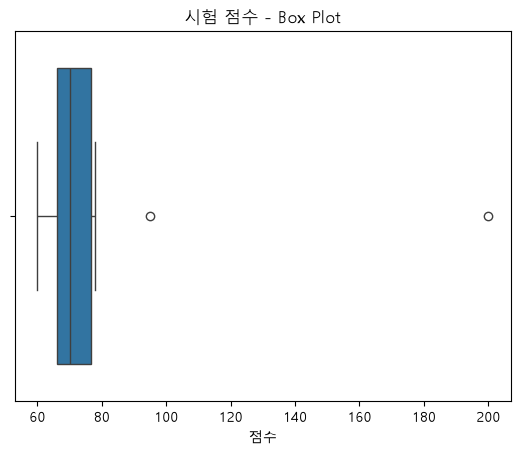

In [ ]:
# 3. 박스플롯
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()


In [10]:
# 4. Z-score 방법
print()
print("===== Z-score 방법 =====")


# 기술 통계량은 같은 데이터를 사용해도 NumPy 배열과 Pandas Series는 제공하는 기능과 기본값에 차이가 있다.
# NumPy는 주로 모집단을 기준으로 하고, Pandas는 표본을 기준으로 한다.

# 평균
mean = scores_np.mean()

# 분산
variance = scores_np.var()

# 표준편차
std = scores_np.std()

print("평균:", round(mean, 2))
print("분산:", round(variance, 2))
print("표준편차:", round(std, 2))


# Z-score 계산
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))


===== Z-score 방법 =====
평균: 82.91
분산: 1453.36
표준편차: 38.12
Z-score:
[-0.6  -0.55 -0.47 -0.42 -0.39 -0.34 -0.29 -0.21 -0.13  0.32  3.07]


In [11]:
# 5. Z-score 이상치 판단

outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-score 이상치:")
print(outliers_z)


Z-score 이상치:
[200]


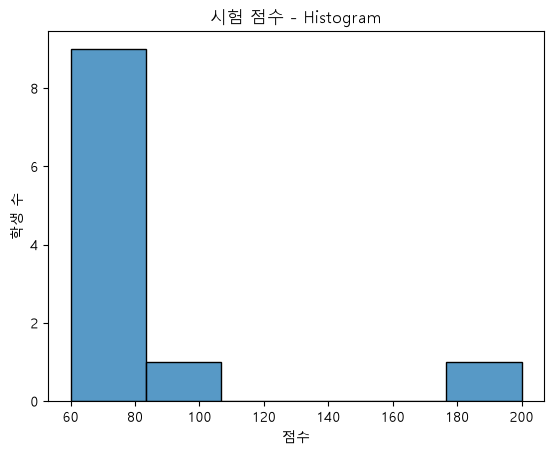

In [12]:
# 6. 히스토그램

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()